# Generate state vector netcdf file from shape file

Use this notebook to create an IMI state vector file for an irregular region of interest using a shape file for the region.

- Step 1: Upload the shape file to EC2
- Step 2: Copy the path to the shape file into the configuration file (config.yml)
- Step 3: Open this notebook (instructions: https://docs.aws.amazon.com/dlami/latest/devguide/setup-jupyter.html)
- Step 4: Run the notebook
- Step 5: When satisfied with the state vector, set save switch in final cell to True and save the netcdf

Example here is for the Permian Basin.

In [1]:
import sys
import xarray as xr 
import numpy as np
import fiona
import regionmask
import xesmf as xe
import geopandas as gpd
import pandas as pd
import cartopy.crs as ccrs
from sklearn.cluster import KMeans
import colorcet as cc
import matplotlib
import matplotlib.pyplot as plt
import yaml
import warnings; warnings.filterwarnings(action='ignore')
sys.path.append('../../')
from shapely.ops import polygonize
from shapely.geometry import MultiLineString
from src.utilities.make_state_vector_file import cluster_buffer_elements
from src.utilities.utils import download_landcover_files, download_hemcodiags_files
%matplotlib inline

## Setup

In [2]:
# Read config file
config = yaml.load(
    open("/n/home12/mhe/integrated_methane_inversion/config_annual_ensemble.yml"), Loader=yaml.FullLoader
)

In [4]:
# Download landcover files from s3 if not already present
# download_landcover_files(config)
# download_hemcodiags_files(config)

In [5]:
# OPTIONAL: convert polylines to polygons
# gdf = gpd.read_file("./shapefiles/regions/congo_basin.shp")

# # extract and combine all line geometries into a single MultiLineString
# lines = [geom for geom in gdf.geometry if geom is not None]
# multi_line = MultiLineString([line for line in lines])

# # onvert lines to polygons
# polygons = list(polygonize(multi_line))

# # new GDF with the polygon geometries
# polygon_gdf = gpd.GeoDataFrame(geometry=polygons, crs=gdf.crs)
# polygon_gdf['dissolve'] = 1
# combined_gdf = polygon_gdf.dissolve(by='dissolve')
# combined_gdf.to_file("./shapefiles/regions/congo_basin2.shp")

In [6]:
# OPTIONAL: convert polygons to 1 multipolygon
# gdf = gpd.read_file("./shapefiles/regions/wsl.shp")
# gdf['dissolve'] = 1
# combined_gdf = gdf.dissolve(by='dissolve')
# combined_gdf.to_file("./shapefiles/regions/wsl_2.shp")

In [3]:
# Open shape file with geopandas
shape = gpd.read_file("./shapefiles/regions/kr.shp")
shape

,id,name,source,geometry
0,KR42,Gangwon,https://simplemaps.com,"POLYGON ((129.42262 36.61664, 129.41260 36.616..."
1,KR41,Gyeonggi,https://simplemaps.com,"MULTIPOLYGON (((126.98587 38.20540, 126.98587 ..."
2,KR44,South Chungcheong,https://simplemaps.com,"MULTIPOLYGON (((126.96169 36.90511, 126.96200 ..."
3,KR28,Incheon,https://simplemaps.com,"MULTIPOLYGON (((126.60379 37.54930, 126.64933 ..."
4,KR45,North Jeolla,https://simplemaps.com,"MULTIPOLYGON (((126.81208 36.04730, 126.85709 ..."
5,KR46,South Jeolla,https://simplemaps.com,"MULTIPOLYGON (((126.43690 35.37056, 126.43707 ..."
6,KR48,South Gyeongsang,https://simplemaps.com,"MULTIPOLYGON (((127.61746 35.27663, 127.63844 ..."
7,KR26,Busan,https://simplemaps.com,"POLYGON ((128.96278 35.13339, 128.97107 35.145..."
8,KR31,Ulsan,https://simplemaps.com,"POLYGON ((129.26884 35.31572, 129.26480 35.318..."
9,KR47,North Gyeongsang,https://simplemaps.com,"MULTIPOLYGON (((128.65027 37.02226, 128.67590 ..."


In [4]:
shape = shape.to_crs("EPSG:4326")

In [5]:
# Define min/max latitude and longitude for inversion domain
buffer_deg = config["BufferDeg"]
if config["Res"] == "4.0x5.0":
    deg_lat, deg_lon = 4.0, 5.0
elif config["Res"] == "2.0x2.5":
    deg_lat, deg_lon = 2.0, 2.5
elif config["Res"] == "0.5x0.625":
    deg_lat, deg_lon = 0.5, 0.625
elif config["Res"] == "0.25x0.3125":
    deg_lat, deg_lon = 0.25, 0.3125
bufferdeg_min_lat = deg_lat * 3
bufferdeg_min_lon = deg_lon * 3

# set the buffer degrees to the maximum to ensure
# that the buffer is at least the minimum (3 extra grid cells on each side)
buffer_deg_lat = max(buffer_deg, bufferdeg_min_lat)
buffer_deg_lon = max(buffer_deg, bufferdeg_min_lon)

bounds = shape.bounds
lon_min = bounds["minx"][0] - buffer_deg_lon
lon_max = bounds["maxx"][0] + buffer_deg_lon
lat_min = bounds["miny"][0] - buffer_deg_lat
lat_max = bounds["maxy"][0] + buffer_deg_lat

# Create lat/lon grid (can increase dlon, dlat if the regridding in next steps is slow)
dlon = 0.1
dlat = 0.1
lon = np.arange(lon_min, lon_max + dlon, dlon)
lat = np.arange(lat_min, lat_max + dlat, dlat)

# Inversion spatial resolution
if config["Res"] == "0.25x0.3125":
    lat_res = 0.25
    lon_res = 0.3125
elif config["Res"] == "0.5x0.625":
    lat_res = 0.5
    lon_res = 0.625
elif config["Res"] == "2.0x2.5":
    lat_res = 2.0
    lon_res = 2.5

## Create region of interest mask from shape file

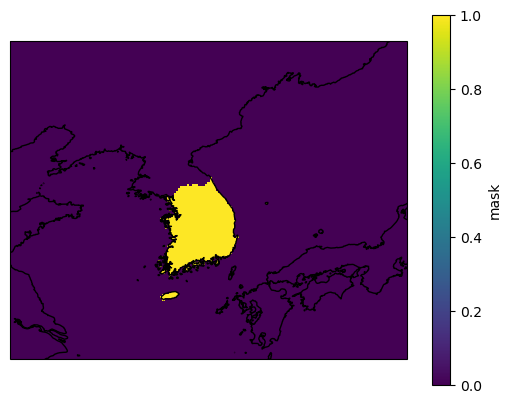

In [18]:
# Make mask from shape file
mask = (
    regionmask.mask_geopandas(shape, lon, lat) + 1
)  # Add 1 so the mask values are 1 instead of 0
mask = xr.where(mask.notnull(), 1, 0)

# View the mask in the inversion domain
f, ax = plt.subplots(subplot_kw=dict(projection=ccrs.PlateCarree()))
mask.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    add_colorbar=True,
)

ax.coastlines()

In [19]:
mask.values

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [21]:
mask.to_netcdf('~/global_OH/masks/kr_mask.nc')

## Regrid mask to 0.25 x 0.3125 or 0.5x0.625 grid

In [16]:
# Need to regrid to the grid HEMCO expects
reference_lat_grid = np.arange(-90, 90 + lat_res, lat_res)
reference_lon_grid = np.arange(-180, 180 + lon_res, lon_res)

# Find closest reference coordinates to selected lat/lon bounds
lat_min = reference_lat_grid[np.abs(reference_lat_grid - lat_min).argmin()]
lon_min = reference_lon_grid[np.abs(reference_lon_grid - lon_min).argmin()]
lat_max = reference_lat_grid[np.abs(reference_lat_grid - lat_max).argmin()]
lon_max = reference_lon_grid[np.abs(reference_lon_grid - lon_max).argmin()]

# Create an xESMF regridder object to resample the mask on the grid HEMCO expects
new_lat_grid = np.arange(lat_min, lat_max + lat_res, lat_res)
new_lon_grid = np.arange(lon_min, lon_max + lon_res, lon_res)
ds_out = xr.Dataset(
    {
        "lat": (["lat"], new_lat_grid),
        "lon": (["lon"], new_lon_grid),
    }
)
# ds_out = ds_out.rename({'longitude': 'lon', 'latitude': 'lat'})

regridder = xe.Regridder(mask, ds_out, "nearest_s2d")
regridder

xESMF Regridder 
Regridding algorithm:       nearest_s2d 
Weight filename:            nearest_s2d_142x177_8x8.nc 
Reuse pre-computed weights? False 
Input grid shape:           (142, 177) 
Output grid shape:          (8, 8) 
Periodic in longitude?      False

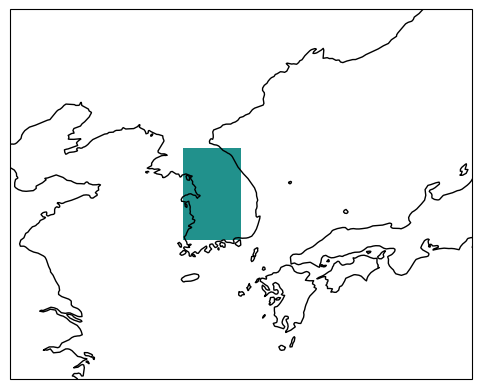

In [17]:
# Regrid the mask
mask = regridder(mask)

# View the regridded mask in the inversion domain
f, ax = plt.subplots(subplot_kw=dict(projection=ccrs.PlateCarree()))
mask.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
)
ax.coastlines()

In [ ]:
mask.to_netcdf('./shapefiles/masks/korea.nc')

----